In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

In [15]:
df = pd.read_csv(
    "../data/processed/upi_transactions_processed.csv",
    parse_dates=["timestamp"]
)

In [16]:
print("=" * 60)
print("UPI TRANSACTION INTELLIGENCE PLATFORM")
print("Exploratory Data Analysis")
print("=" * 60)

print(f"Rows               : {df.shape[0]:,}")
print(f"Columns            : {df.shape[1]}")
print(f"Missing Values     : {df.isnull().sum().sum()}")
print(f"Duplicate Records  : {df.duplicated().sum()}")

UPI TRANSACTION INTELLIGENCE PLATFORM
Exploratory Data Analysis
Rows               : 250,000
Columns            : 17
Missing Values     : 0
Duplicate Records  : 0


In [17]:
df.dtypes

transaction_id                object
timestamp             datetime64[ns]
transaction_type              object
merchant_category             object
amount_inr                     int64
transaction_status            object
sender_age_group              object
receiver_age_group            object
sender_state                  object
sender_bank                   object
receiver_bank                 object
device_type                   object
network_type                  object
fraud_flag                     int64
hour_of_day                    int64
day_of_week                   object
is_weekend                     int64
dtype: object

In [18]:
df.head()

,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [20]:
## 6.2.1 Transaction Type Distribution

### Business Question
# Which transaction type is most frequently used in the dataset?

### Objective
# To analyze the frequency and percentage distribution of UPI transaction types.

In [ ]:
## Frequency Distribution of Transaction Types
transaction_type = (
    df["transaction_type"]
      .value_counts()
      .reset_index()
)

transaction_type.columns = [
    "Transaction Type",
    "Transaction Count"
]

transaction_type

,Transaction Type,Transaction Count
0,P2P,112445
1,P2M,87660
2,Bill Payment,37368
3,Recharge,12527


In [ ]:
## Percentage Distribution of Transaction Types
transaction_type["Percentage"] = (
    transaction_type["Transaction Count"]
    / transaction_type["Transaction Count"].sum()
    * 100
).round(2)

transaction_type

,Transaction Type,Transaction Count,Percentage
0,P2P,112445,44.98
1,P2M,87660,35.06
2,Bill Payment,37368,14.95
3,Recharge,12527,5.01


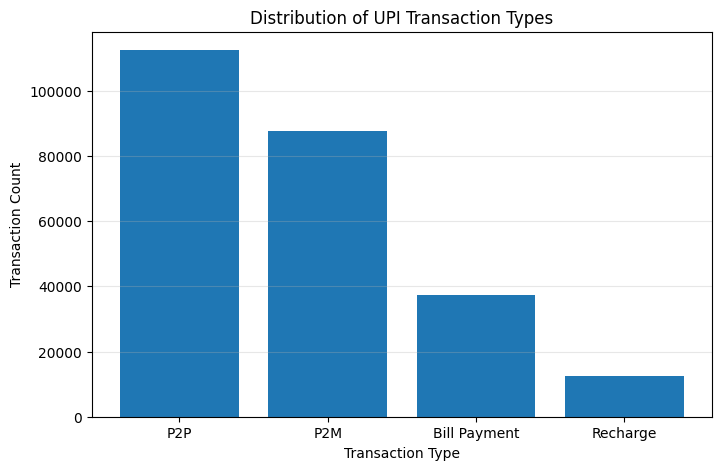

In [ ]:
## Bar Chart Visualization 
plt.figure(figsize=(8,5))

plt.bar(
    transaction_type["Transaction Type"],
    transaction_type["Transaction Count"]
)

plt.title("Distribution of UPI Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Count")

plt.grid(axis="y", alpha=0.3)

plt.show()

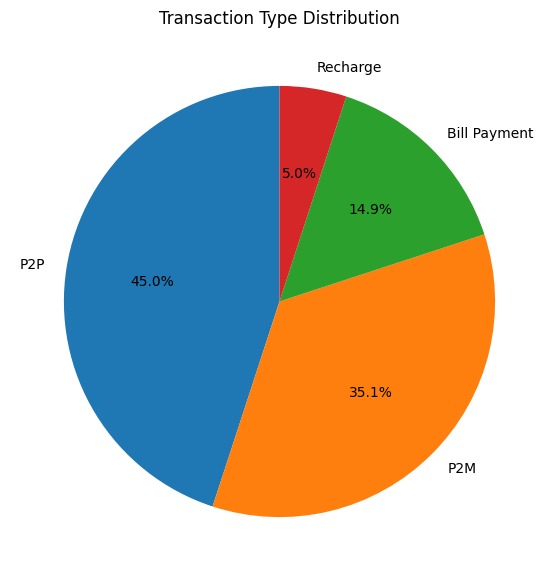

In [ ]:
## Pie Chart Visualization
plt.figure(figsize=(7,7))

plt.pie(
    transaction_type["Transaction Count"],
    labels=transaction_type["Transaction Type"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Transaction Type Distribution")

plt.show()

In [ ]:
## Most Frequently Used Transaction Type
transaction_type.iloc[0]

Transaction Type        P2P
Transaction Count    112445
Percentage            44.98
Name: 0, dtype: object

In [ ]:
## 6.2.2 Merchant Category Distribution

### Business Question
# Which merchant categories receive the highest number of UPI transactions?

### Objective
# To analyze the distribution of merchant categories and identify the categories with the highest transaction volume.

In [26]:
merchant_category = (
    df["merchant_category"]
    .value_counts()
    .reset_index()
)

merchant_category.columns = [
    "Merchant Category",
    "Transaction Count"
]

merchant_category

,Merchant Category,Transaction Count
0,Grocery,49966
1,Food,37464
2,Shopping,29872
3,Fuel,25063
4,Other,24828
5,Utilities,22338
6,Transport,20105
7,Entertainment,20103
8,Healthcare,12663
9,Education,7598


In [27]:
merchant_category["Percentage"] = (
    merchant_category["Transaction Count"]
    / merchant_category["Transaction Count"].sum()
    * 100
).round(2)

merchant_category

,Merchant Category,Transaction Count,Percentage
0,Grocery,49966,19.99
1,Food,37464,14.99
2,Shopping,29872,11.95
3,Fuel,25063,10.03
4,Other,24828,9.93
5,Utilities,22338,8.94
6,Transport,20105,8.04
7,Entertainment,20103,8.04
8,Healthcare,12663,5.07
9,Education,7598,3.04


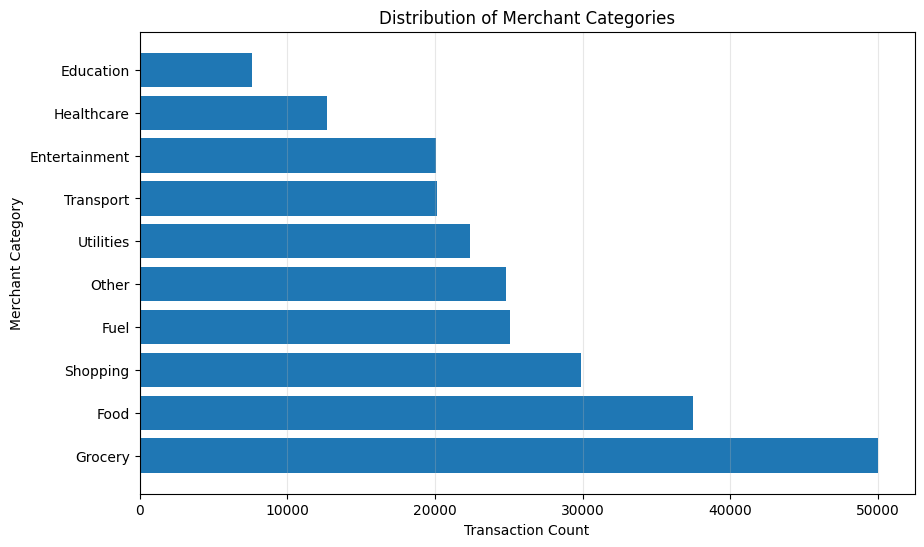

In [28]:
plt.figure(figsize=(10,6))

plt.barh(
    merchant_category["Merchant Category"],
    merchant_category["Transaction Count"]
)

plt.title("Distribution of Merchant Categories")
plt.xlabel("Transaction Count")
plt.ylabel("Merchant Category")

plt.grid(axis="x", alpha=0.3)

plt.show()

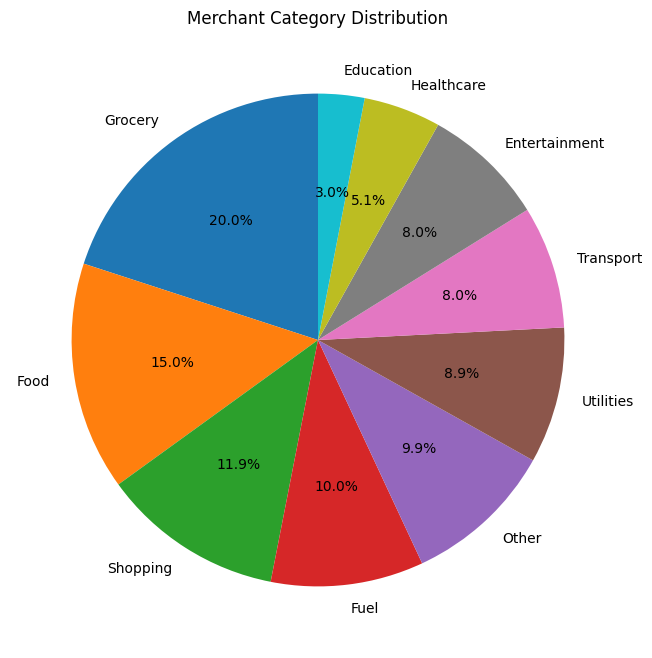

In [29]:
plt.figure(figsize=(8,8))

plt.pie(
    merchant_category["Transaction Count"],
    labels=merchant_category["Merchant Category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Merchant Category Distribution")

plt.show()

In [30]:
merchant_category.iloc[0]

Merchant Category    Grocery
Transaction Count      49966
Percentage             19.99
Name: 0, dtype: object

In [ ]:
## 6.2.3 Transaction Status Distribution

### Business Question

# What proportion of UPI transactions are successful and failed?

### Objective

# To measure transaction outcomes and establish the dataset’s overall transaction success and failure rates.

In [31]:
status_distribution = (
    df["transaction_status"]
    .value_counts()
    .rename_axis("Transaction Status")
    .reset_index(name="Transaction Count")
)

status_distribution["Percentage"] = (
    status_distribution["Transaction Count"]
    .div(status_distribution["Transaction Count"].sum())
    .mul(100)
    .round(2)
)

status_distribution

,Transaction Status,Transaction Count,Percentage
0,SUCCESS,237624,95.05
1,FAILED,12376,4.95


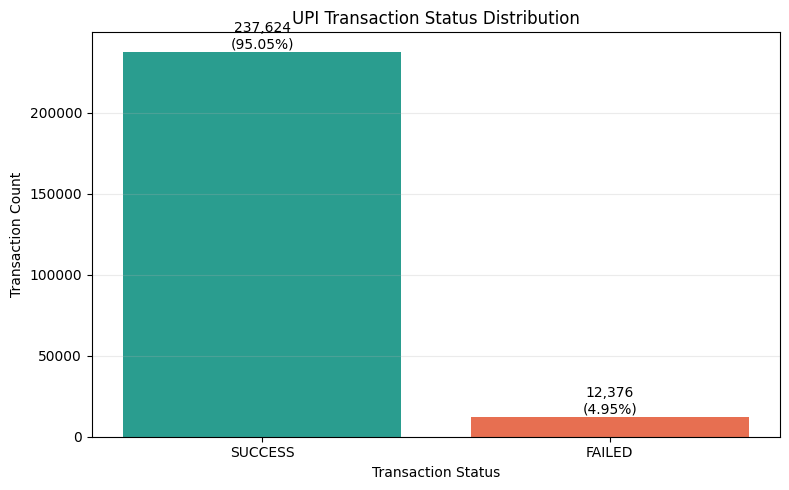

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    status_distribution["Transaction Status"],
    status_distribution["Transaction Count"],
    color=["#2A9D8F", "#E76F51"]
)

ax.set_title("UPI Transaction Status Distribution")
ax.set_xlabel("Transaction Status")
ax.set_ylabel("Transaction Count")
ax.grid(axis="y", alpha=0.25)

for bar, count, percentage in zip(
    bars,
    status_distribution["Transaction Count"],
    status_distribution["Percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [33]:
total_transactions = len(df)

successful_transactions = (
    df["transaction_status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("success")
    .sum()
)

failed_transactions = total_transactions - successful_transactions

success_rate = successful_transactions / total_transactions * 100
failure_rate = failed_transactions / total_transactions * 100

print(f"Total transactions      : {total_transactions:,}")
print(f"Successful transactions : {successful_transactions:,}")
print(f"Failed transactions     : {failed_transactions:,}")
print(f"Success rate            : {success_rate:.2f}%")
print(f"Failure rate            : {failure_rate:.2f}%")

Total transactions      : 250,000
Successful transactions : 237,624
Failed transactions     : 12,376
Success rate            : 95.05%
Failure rate            : 4.95%


In [ ]:
## 6.2.4 Transaction Amount Distribution

### Business Question

# How are UPI transaction amounts distributed, and are there unusually high-value transactions?

### Objective

# To examine the central tendency, spread, skewness, and potential outliers in transaction amounts.

In [34]:
amount_summary = df["amount_inr"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

amount_summary

count    250000.000000
mean       1311.756036
std        1848.059224
min          10.000000
25%         288.000000
50%         629.000000
75%        1596.000000
90%        3236.000000
95%        4687.050000
99%        9003.010000
max       42099.000000
Name: amount_inr, dtype: float64

In [35]:
amount_statistics = pd.Series({
    "Mean": df["amount_inr"].mean(),
    "Median": df["amount_inr"].median(),
    "Mode": df["amount_inr"].mode().iloc[0],
    "Minimum": df["amount_inr"].min(),
    "Maximum": df["amount_inr"].max(),
    "Standard Deviation": df["amount_inr"].std(),
    "Skewness": df["amount_inr"].skew()
}).round(2)

amount_statistics

Mean                   1311.76
Median                  629.00
Mode                    215.00
Minimum                  10.00
Maximum               42099.00
Standard Deviation     1848.06
Skewness                  3.92
dtype: float64

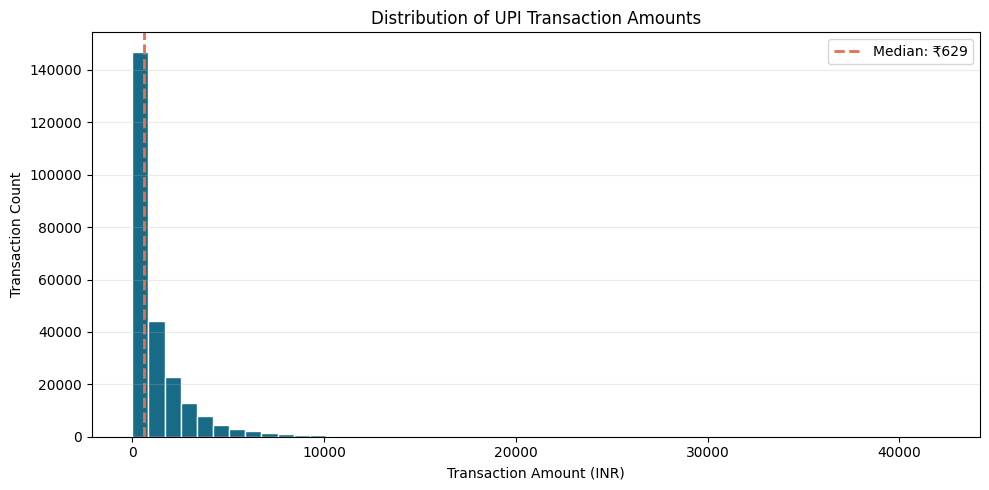

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["amount_inr"],
    bins=50,
    color="#176B87",
    edgecolor="white"
)

ax.axvline(
    df["amount_inr"].median(),
    color="#E76F51",
    linestyle="--",
    linewidth=2,
    label=f'Median: ₹{df["amount_inr"].median():,.0f}'
)

ax.set_title("Distribution of UPI Transaction Amounts")
ax.set_xlabel("Transaction Amount (INR)")
ax.set_ylabel("Transaction Count")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [37]:
q1 = df["amount_inr"].quantile(0.25)
q3 = df["amount_inr"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

potential_outliers = df[
    (df["amount_inr"] < lower_bound) |
    (df["amount_inr"] > upper_bound)
]

print(f"Q1                  : ₹{q1:,.2f}")
print(f"Q3                  : ₹{q3:,.2f}")
print(f"IQR                 : ₹{iqr:,.2f}")
print(f"Lower bound         : ₹{lower_bound:,.2f}")
print(f"Upper bound         : ₹{upper_bound:,.2f}")
print(f"Potential outliers  : {len(potential_outliers):,}")
print(
    f"Outlier percentage  : "
    f"{len(potential_outliers) / len(df) * 100:.2f}%"
)

Q1                  : ₹288.00
Q3                  : ₹1,596.00
IQR                 : ₹1,308.00
Lower bound         : ₹-1,674.00
Upper bound         : ₹3,558.00
Potential outliers  : 21,171
Outlier percentage  : 8.47%
